# Logical CNOT — Transversal

The transversal CNOT applies a physical CNOT between corresponding qubits of
two surface code patches (control and target), implementing the logical CNOT.

Five sub-experiments probe all combinations of logical input/output bases:

| Sub-experiment | Init C | Init T | Meas C | Meas T | Tests |
|---|---|---|---|---|---|
| ZZ_ZZ | Z | Z | Z | Z | Z_C, Z_C Z_T |
| ZX_ZX | Z | X | Z | X | Z_C, X_T |
| XZ_XX | X | Z | X | X | X_C X_T, X_T |
| XZ_ZZ | X | Z | Z | Z | X_C X_T, Z_C Z_T |
| XX_XX | X | X | X | X | X_C X_T, X_T |

Average over the sub-experiments to get a comprehensive LER estimation of the protocol: 1/4 * (ZZ_ZZ + ZX_ZX + 1/2 * (XZ_XX + XZ_ZZ) + XX_XX).  
Code: Unrotated Surface Code, d=3, p=1e-3.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.cnot_trans import CNOTTransExperiment
from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode, UnrotatedSurfaceCodeExtractionBlock,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2 # constant SE rounds is sufficient in the transversal gate case
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

CNOT_SUB_EXPERIMENTS = [
    # (label,  init_C, init_T, meas_C, meas_T)
    ("ZZ_ZZ", "Z", "Z", "Z", "Z"),
    ("ZX_ZX", "Z", "X", "Z", "X"),
    ("XZ_XX", "X", "Z", "X", "X"),
    ("XZ_ZZ", "X", "Z", "Z", "Z"),
    ("XX_XX", "X", "X", "X", "X"),
]

## Build Circuits

In [3]:
circuits = {}
for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTTransExperiment(
            code_patch_class=UnrotatedSurfaceCode,
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            code_params_control={"distance": d},
            offset_target=(2 * d, 0),
            initial_basis_control=ic,
            initial_basis_target=it,
            measure_basis_control=mc,
            measure_basis_target=mt,
            rounds_before=rounds,
            rounds_after=rounds,
            noise_params=noise_params,
        )
        circuits[sub] = exp.build()
    c = circuits[sub]
    print(f"{sub}: {c.num_qubits} qubits, {c.num_detectors} detectors, {c.num_observables} observables")

ZZ_ZZ: 50 qubits, 96 detectors, 2 observables
ZX_ZX: 50 qubits, 96 detectors, 2 observables
XZ_XX: 50 qubits, 96 detectors, 1 observables
XZ_ZZ: 50 qubits, 96 detectors, 1 observables
XX_XX: 50 qubits, 96 detectors, 2 observables


## Detector Slice for sub-experiments

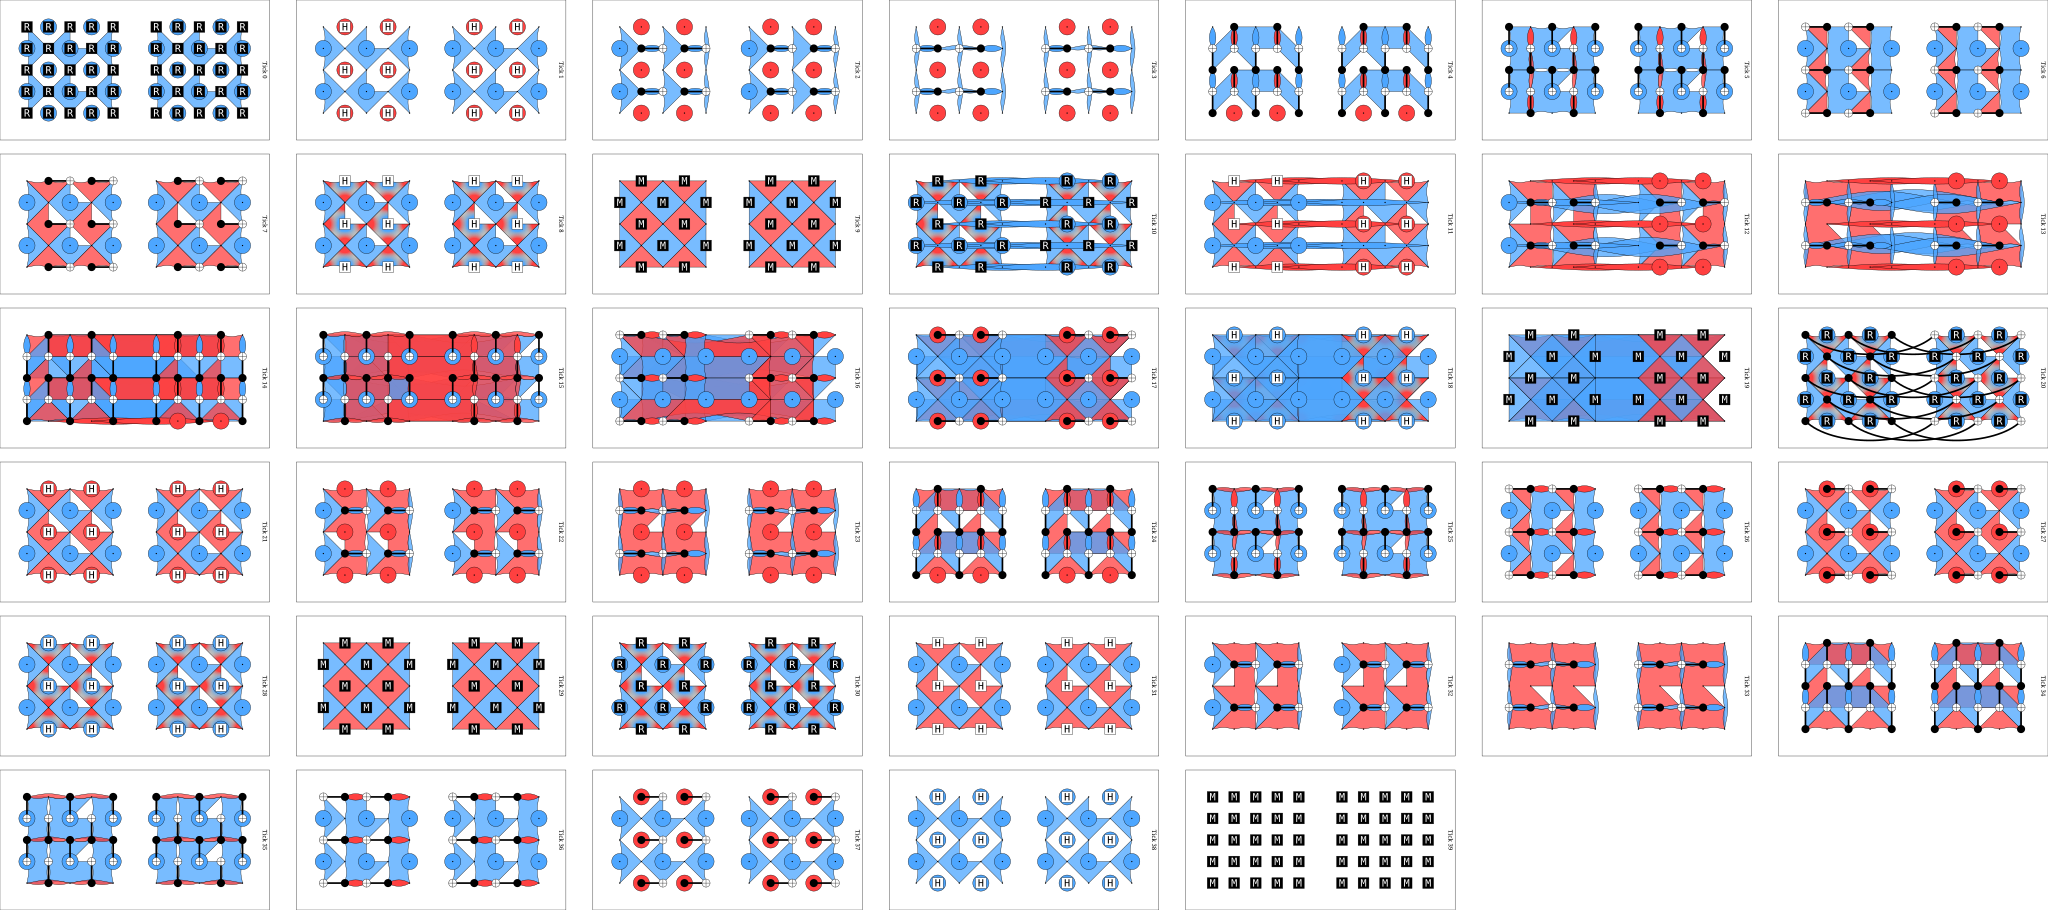

In [4]:
circuits["ZZ_ZZ"].without_noise().diagram("detslice-with-ops-svg") # other sub-experiments ZX_ZX, XZ_XX, XZ_ZZ, XX_XX

## Noiseless Sanity Check

In [5]:
for sub, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{sub}: clean={not det.any() and not obs.any()}")

ZZ_ZZ: clean=True
ZX_ZX: clean=True
XZ_XX: clean=True
XZ_ZZ: clean=True
XX_XX: clean=True


## Simulation with BP+OSD (100k shots each)

BP+OSD is used because transversal CNOT introduces non-CSS detector correlations.

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("bposd", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

results = {}
for sub, circ in circuits.items():
    stats = pipeline.run(circ)
    results[sub] = stats
    print(f"{sub}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

ZZ_ZZ: LER=2.05e-03  (123 errors / 60,000 shots)
ZX_ZX: LER=2.32e-03  (139 errors / 60,000 shots)
XZ_XX: LER=1.70e-03  (102 errors / 60,000 shots)
XZ_ZZ: LER=1.37e-03  (96 errors / 70,000 shots)
XX_XX: LER=2.30e-03  (138 errors / 60,000 shots)


## LER vs Physical Error Rate

Sweep the physical error rate `p ∈ {1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2}` and plot the **mean logical error rate over the 5 sub-experiments**, one curve per code distance. The transversal CNOT is a single-time-slice logical gate, so a *constant* `rounds_before = rounds_after = 2` already suffices — unlike lattice surgery there is no `rounds = d` scaling — yet the spatial code distance alone suppresses the LER below threshold (`LER(d=5) < LER(d=3)`), the two curves crossing in the threshold region (`p ≈ 5e-3`–`1e-2`).

Decoding uses **BP+OSD** (the transversal CNOT induces non-CSS detector correlations). The sweep runs the GPU `nv-qldpc-decoder` — the *same* BP+OSD algorithm as the CPU `bposd` cell above — because CPU BP+OSD is ~100–1000× slower at `d = 5`, which would make the sweep intractable.

> Same sweep settings as `logical_CNOT_LS_unrotated.ipynb` (identical `P_SWEEP`, `DISTANCES`, `max_shots`, `max_errors`, and plotting), so this figure is directly comparable to the lattice-surgery CNOT.

  d         p   mean LER (over 5 sub-experiments)
------------------------------------------------
  3     1e-03   1.874e-03
  3     2e-03   8.000e-03
  3     3e-03   1.668e-02
  3     5e-03   4.434e-02
  3     7e-03   8.240e-02
  3     1e-02   1.563e-01
  5     1e-03   1.070e-04
  5     2e-03   9.250e-04
  5     3e-03   3.523e-03
  5     5e-03   2.160e-02
  5     7e-03   6.496e-02
  5     1e-02   1.774e-01


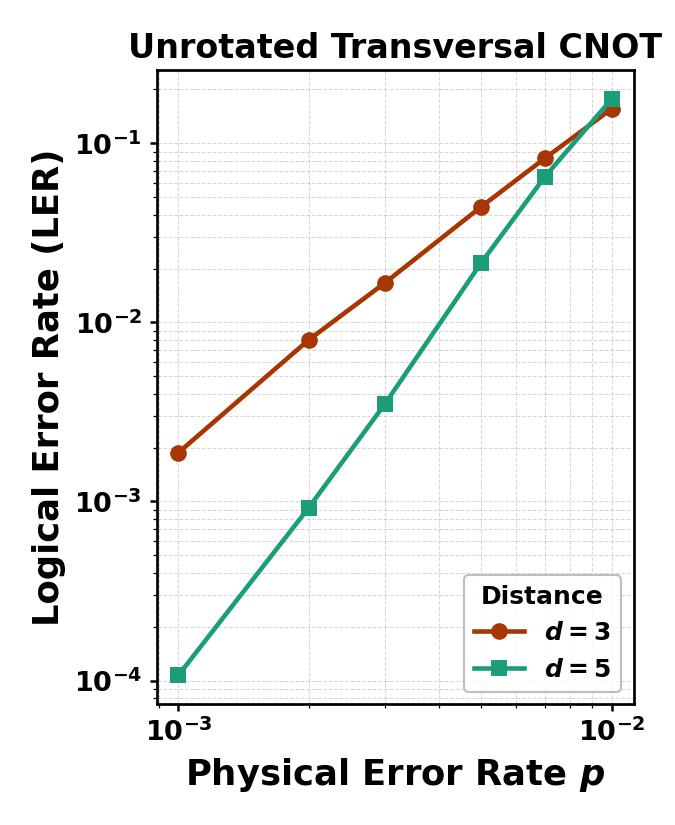

In [7]:
# ── LER vs Physical Error Rate ────────────────────────────────────────────────
# Sweep the physical error rate and plot the mean logical error rate over the 5
# sub-experiments, one curve per code distance. The transversal CNOT is a single
# time-slice logical gate, so constant rounds_before = rounds_after = rounds (= 2)
# is sufficient — no rounds = d scaling — yet the spatial code distance still
# suppresses the LER below threshold (LER(d=5) < LER(d=3)); the curves cross in
# the threshold region (p ~ 5e-3 to 1e-2).
#
# BP+OSD decoding is required (transversal CNOT -> non-CSS detector correlations).
# We use the GPU nv-qldpc-decoder (same BP+OSD algorithm as the cpu `bposd` cell
# above) so the d=5 sweep is tractable; cpu BP+OSD is ~100-1000x slower at d=5.
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from lightstim.plot.styles import apply_paper_style, bold_ticks, PALETTE_DISTANCE
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence bold-font warnings

P_SWEEP   = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
DISTANCES = [3, 5]
MARKERS   = {3: "o", 5: "s", 7: "^"}

sweep_pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("nv-qldpc-decoder", backend="gpu", params={
        "max_iterations": 1000, "osd_order": 10, "bp_method": "min_sum",
        "ms_scaling_factor": 0, "osd_method": "osd_cs", "use_osd": True,
    }),
    max_shots=200_000,
    max_errors=60,
    num_workers=1,
    print_progress=False,
)

TITLE = "Unrotated Transversal CNOT"

def build_cnot_trans_p(dd, ic, it, mc, mt, pp):
    "Build one transversal-CNOT sub-experiment at distance dd, error rate pp (rounds=2)."
    noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
    with contextlib.redirect_stdout(io.StringIO()):
        exp = CNOTTransExperiment(
            code_patch_class=UnrotatedSurfaceCode,
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            code_params_control={"distance": dd},
            offset_target=(2 * dd, 0),
            initial_basis_control=ic,
            initial_basis_target=it,
            measure_basis_control=mc,
            measure_basis_target=mt,
            rounds_before=rounds,
            rounds_after=rounds,
            noise_params=noise,
        )
        return exp.build()

ler_curves = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   mean LER (over 5 sub-experiments)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        lers = [sweep_pipeline.run(build_cnot_trans_p(dd, ic, it, mc, mt, pp)).logical_error_rate
                for sub, ic, it, mc, mt in CNOT_SUB_EXPERIMENTS]
        mean_ler = float(np.mean(lers))
        ler_curves[dd].append(mean_ler)
        print(f"{dd:>3} {pp:>9.0e}   {mean_ler:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    ax.loglog(P_SWEEP, ler_curves[dd], marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate (LER)")
ax.set_title(TITLE, fontsize=16)  # 16pt so the long title fits the 4.5" width
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
plt.show()